# read in data 

In [1]:
# read in the data 
import pandas as pd
#rivers = pd.read_csv('/Users/lisakelly/Desktop/masters/y1/project_2/progress/april/individual river imputation/machine learning/master_dataset_inputed_with_ndvi.csv')
rivers = pd.read_csv('/Users/lisakelly/Desktop/masters/y1/project_2/progress/may/rivers_2000_onwards.csv')
rivers_original = rivers.copy()

# sanity check 
print(rivers.head())
print(rivers.info())
print(rivers.describe())


rivers["date"] = pd.to_datetime(rivers[["year", "month"]].assign(day=1))
rivers_original["date"] = pd.to_datetime(rivers_original[["year", "month"]].assign(day=1))

rivers = rivers.sort_values("date").set_index("date")
rivers_original = rivers_original.sort_values("date").set_index("date")

rivers.groupby("river")["water_level"].std()

        river  year  month  water_level  runoff  temp_max_observed  \
0   Nyamagana  2000      1          NaN     NaN          33.504850   
1        Jiji  2000      1     0.704516     NaN          21.448387   
2  Kaburantwa  2000      1          NaN    0.71          33.504850   
3    Mulembwe  2000      1     1.239355   20.05          21.448387   
4     Nyengwe  2000      1          NaN   12.99          28.367742   

   temp_min_observed  precip_observed        temp_source      precip_source  \
0          15.512020        30.170508           MPARAMBO           MPARAMBO   
1           9.948387       125.600000       MPOTA (Tora)       MPOTA (Tora)   
2          15.512020        30.459723           MPARAMBO           MPARAMBO   
3           9.948387       125.600000       MPOTA (Tora)       MPOTA (Tora)   
4          18.761290       203.000000  NYANZA LAC (IRAT)  NYANZA LAC (IRAT)   

   ... era5_d2m_mean  era5_msl_mean  temp_max_imputed  temp_min_imputed  \
0  ...     12.748414  101028.

river
Buzimba       0.520737
Jiji          0.232182
Kaburantwa    0.590347
Mpanda        0.302602
Mulembwe      0.621535
Mutimbuzi     0.694357
Nyakagunda    0.105471
Nyamagana     0.284162
Nyengwe       0.389490
Rusizi        0.791287
Name: water_level, dtype: float64

# validation

In [2]:
# ============================================================
# MULTI-MODEL WATER LEVEL IMPUTATION PIPELINE
# Models:
# 1. LightGBM
# 2. XGBoost
# 3. ARIMAX with predictors
# 4. SARIMAX with predictors
# ============================================================

import numpy as np
import pandas as pd

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error


# ============================================================
# SETTINGS
# ============================================================

TARGET_COL = "water_level"
RIVER_COL = "river"
START_YEAR = 2000

MASK_FRACTION = 0.20
RANDOM_SEED = 42
MIN_OBS = 50


# ============================================================
# XGBOOST HYPERPARAMETERS
# Defined once and reused in: validation (ml_models),
# bootstrap imputation, and multi-horizon forecasting.
# Keeping these aligned means the model selected during
# validation is the same model used for the final outputs.
# ============================================================

XGB_PARAMS = dict(
    n_estimators=300,
    learning_rate=0.03,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_SEED,
    objective="reg:squarederror",
    verbosity=0,
)


# ============================================================
# FEATURE ENGINEERING
# ============================================================

def create_features(df, target_col=TARGET_COL):
    df = df.copy()
    df = df.sort_index()

    # Month seasonality
    df["month"] = df.index.month

    # Precipitation lags
    for lag in [1, 2, 3, 6, 12]:
        df[f"precip_lag{lag}"] = df["precip_observed"].shift(lag)

    # Rolling rainfall totals using previous months only
    df["precip_3m"] = df["precip_observed"].shift(1).rolling(3).sum()
    df["precip_6m"] = df["precip_observed"].shift(1).rolling(6).sum()
    df["precip_12m"] = df["precip_observed"].shift(1).rolling(12).sum()

    # Weighted rainfall from previous 3 months
    df["precip_weighted_3m"] = (
        df["precip_observed"].shift(1) * 0.5 +
        df["precip_observed"].shift(2) * 0.3 +
        df["precip_observed"].shift(3) * 0.2
    )

    # Temporary interpolation only for lag creation
    df["water_level_temp"] = (
        df[target_col]
        .interpolate(method="linear")
        .ffill()
        .bfill()
    )

    # Water-level lags
    for lag in [1, 2, 3, 6, 12]:
        df[f"level_lag{lag}"] = df["water_level_temp"].shift(lag)

    return df


# ============================================================
# PREDICTOR LIST
# ============================================================

predictors = [
    "temp_max_observed",
    "temp_min_observed",
    "precip_observed",
    "precip_lag1",
    "precip_lag2",
    "precip_lag3",
    "precip_lag6",
    "precip_lag12",
    "precip_3m",
    "precip_6m",
    "precip_12m",
    "precip_weighted_3m",
    "month",
    "ndvi",
    "level_lag1",
    "level_lag2",
    "level_lag3",
    "level_lag6",
    "level_lag12"
    #,"water_level_m"
]


# ============================================================
# MACHINE LEARNING MODELS
# ============================================================

ml_models = {
    "LightGBM": LGBMRegressor(
        n_estimators=300,
        learning_rate=0.03,
        max_depth=3,
        num_leaves=8,
        min_child_samples=5,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_SEED,
        verbose=-1
    ),

    "XGBoost": XGBRegressor(**XGB_PARAMS)
    

}


# ============================================================
# METRIC FUNCTION
# ============================================================

def calculate_metrics(y_true, y_pred, train_y):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    nrmse = rmse / train_y.std() if train_y.std() != 0 else np.nan

    return rmse, mae, bias, nrmse


# ============================================================
# VALIDATION: ARTIFICIALLY MASK 20% OF OBSERVED VALUES
# ============================================================

validation_results = []
validation_predictions = []

np.random.seed(RANDOM_SEED)

for river_name in rivers[RIVER_COL].dropna().unique():

    df = rivers[rivers[RIVER_COL] == river_name].copy()
    df = df.sort_index()

    # Keep modern NDVI period
    df = df[df.index.year >= START_YEAR].copy()

    observed_idx = df[df[TARGET_COL].notna()].index

    if len(observed_idx) < MIN_OBS:
        print(f"Skipping {river_name}: not enough observed values.")
        continue

    # Artificially mask 20% of observed water levels
    masked_idx = np.random.choice(
        observed_idx,
        size=int(len(observed_idx) * MASK_FRACTION),
        replace=False
    )

    df_val = df.copy()

    true_values = df_val.loc[masked_idx, TARGET_COL].copy()
    df_val.loc[masked_idx, TARGET_COL] = np.nan

    # Create predictors after masking
    df_val = create_features(df_val, target_col=TARGET_COL)

    # Keep rows where predictors exist
    available_predictor_rows = df_val[predictors].notna().any(axis=1)

    train_df = df_val[
        df_val[TARGET_COL].notna() & available_predictor_rows
    ].copy()

    test_df = df_val.loc[masked_idx].copy()
    test_df = test_df[test_df[predictors].notna().any(axis=1)]

    if len(train_df) < MIN_OBS or len(test_df) == 0:
        print(f"Skipping {river_name}: insufficient train/test rows after feature creation.")
        continue

    y_train = train_df[TARGET_COL]
    X_train = train_df[predictors]
    X_test = test_df[predictors]
    y_test = true_values.loc[test_df.index]

    # Impute missing predictor values
    imputer = SimpleImputer(strategy="mean")
    X_train_imp = imputer.fit_transform(X_train)
    X_test_imp = imputer.transform(X_test)

    # --------------------------------------------------------
    # LightGBM and XGBoost validation
    # --------------------------------------------------------

    for model_name, model in ml_models.items():

        model.fit(X_train_imp, y_train)
        preds = model.predict(X_test_imp)

        rmse, mae, bias, nrmse = calculate_metrics(y_test, preds, y_train)

        validation_results.append({
            "river": river_name,
            "model": model_name,
            "n_train": len(train_df),
            "n_test_masked": len(test_df),
            "rmse": rmse,
            "mae": mae,
            "bias": bias,
            "nrmse": nrmse
        })

        validation_predictions.append(pd.DataFrame({
            "river": river_name,
            "model": model_name,
            "date": test_df.index,
            "true_water_level": y_test.values,
            "predicted_water_level": preds,
            "error": preds - y_test.values
        }))

    # --------------------------------------------------------
    # ARIMAX validation
    # ARIMAX = SARIMAX with exogenous predictors but no seasonal term
    # --------------------------------------------------------

    try:
        df_arimax = df_val.copy()
        df_arimax = df_arimax[df_arimax[predictors].notna().any(axis=1)].copy()

        y_arimax = df_arimax[TARGET_COL]
        X_arimax = df_arimax[predictors]

        arimax_imputer = SimpleImputer(strategy="mean")
        X_arimax_imp = arimax_imputer.fit_transform(X_arimax)

        arimax_model = SARIMAX(
            y_arimax,
            exog=X_arimax_imp,
            order=(1, 0, 1),
            seasonal_order=(0, 0, 0, 0),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        arimax_fit = arimax_model.fit(disp=False)

        arimax_pred_all = arimax_fit.predict(
            start=0,
            end=len(df_arimax) - 1,
            exog=X_arimax_imp
        )

        arimax_preds = pd.Series(
            arimax_pred_all,
            index=df_arimax.index
        ).loc[test_df.index]

        rmse, mae, bias, nrmse = calculate_metrics(y_test, arimax_preds, y_train)

        validation_results.append({
            "river": river_name,
            "model": "ARIMAX",
            "n_train": len(train_df),
            "n_test_masked": len(test_df),
            "rmse": rmse,
            "mae": mae,
            "bias": bias,
            "nrmse": nrmse
        })

        validation_predictions.append(pd.DataFrame({
            "river": river_name,
            "model": "ARIMAX",
            "date": test_df.index,
            "true_water_level": y_test.values,
            "predicted_water_level": arimax_preds.values,
            "error": arimax_preds.values - y_test.values
        }))

    except Exception as e:
        print(f"ARIMAX failed for {river_name}: {e}")

    # --------------------------------------------------------
    # SARIMAX validation
    # SARIMAX includes monthly seasonality
    # --------------------------------------------------------

    try:
        df_sarimax = df_val.copy()
        df_sarimax = df_sarimax[df_sarimax[predictors].notna().any(axis=1)].copy()

        y_sarimax = df_sarimax[TARGET_COL]
        X_sarimax = df_sarimax[predictors]

        sarimax_imputer = SimpleImputer(strategy="mean")
        X_sarimax_imp = sarimax_imputer.fit_transform(X_sarimax)

        sarimax_model = SARIMAX(
            y_sarimax,
            exog=X_sarimax_imp,
            order=(1, 0, 1),
            seasonal_order=(1, 0, 1, 12),
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        sarimax_fit = sarimax_model.fit(disp=False)

        sarimax_pred_all = sarimax_fit.predict(
            start=0,
            end=len(df_sarimax) - 1,
            exog=X_sarimax_imp
        )

        sarimax_preds = pd.Series(
            sarimax_pred_all,
            index=df_sarimax.index
        ).loc[test_df.index]

        rmse, mae, bias, nrmse = calculate_metrics(y_test, sarimax_preds, y_train)

        validation_results.append({
            "river": river_name,
            "model": "SARIMAX",
            "n_train": len(train_df),
            "n_test_masked": len(test_df),
            "rmse": rmse,
            "mae": mae,
            "bias": bias,
            "nrmse": nrmse
        })

        validation_predictions.append(pd.DataFrame({
            "river": river_name,
            "model": "SARIMAX",
            "date": test_df.index,
            "true_water_level": y_test.values,
            "predicted_water_level": sarimax_preds.values,
            "error": sarimax_preds.values - y_test.values
        }))

    except Exception as e:
        print(f"SARIMAX failed for {river_name}: {e}")


# ============================================================
# MODEL COMPARISON TABLES
# ============================================================

validation_results_df = pd.DataFrame(validation_results)
validation_predictions_df = pd.concat(validation_predictions, ignore_index=True)

# Overall model comparison
model_comparison = (
    validation_results_df
    .groupby("model")
    .agg(
        mean_rmse=("rmse", "mean"),
        median_rmse=("rmse", "median"),
        mean_mae=("mae", "mean"),
        median_mae=("mae", "median"),
        mean_bias=("bias", "mean"),
        mean_nrmse=("nrmse", "mean"),
        median_nrmse=("nrmse", "median"),
        rivers_tested=("river", "nunique")
    )
    .reset_index()
    .sort_values("mean_nrmse")
)

# Best model per river
best_model_per_river = (
    validation_results_df
    .sort_values(["river", "nrmse"])
    .groupby("river")
    .first()
    .reset_index()
)

# Count how often each model wins
model_win_counts = (
    best_model_per_river["model"]
    .value_counts()
    .reset_index()
)

model_win_counts.columns = ["model", "number_of_rivers_best"]


print("Overall model comparison:")
display(model_comparison)

print("Best model per river:")
display(best_model_per_river)

print("Number of rivers where each model performed best:")
display(model_win_counts)


# ============================================================
# SELECT OVERALL BEST MODEL
# ============================================================

overall_best_model = model_comparison.iloc[0]["model"]

print(f"Overall best model based on mean NRMSE: {overall_best_model}")






/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/opt/anaconda3/lib/python3.12/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequ

Overall model comparison:


/opt/anaconda3/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


,model,mean_rmse,median_rmse,mean_mae,median_mae,mean_bias,mean_nrmse,median_nrmse,rivers_tested
3,XGBoost,0.158146,0.132716,0.110252,0.092818,-0.015781,0.356931,0.351114,10
1,LightGBM,0.163098,0.136154,0.112531,0.092805,-0.015743,0.368457,0.363068,10
0,ARIMAX,1.167626,0.135275,0.257055,0.100723,-0.155341,1.955381,0.427734,10
2,SARIMAX,1.169711,0.139532,0.257992,0.104383,-0.155528,1.962481,0.430171,10


Best model per river:


,river,model,n_train,n_test_masked,rmse,mae,bias,nrmse
0,Buzimba,LightGBM,107,26,0.147318,0.117729,-0.001405,0.291318
1,Jiji,LightGBM,239,59,0.087998,0.057527,-0.005879,0.372518
2,Kaburantwa,LightGBM,150,37,0.142750,0.094148,-0.016277,0.242057
3,Mpanda,ARIMAX,137,34,0.140719,0.102379,0.010661,0.479810
4,Mulembwe,XGBoost,208,51,0.244330,0.178857,0.012628,0.382792
5,Mutimbuzi,SARIMAX,86,21,0.372920,0.232581,-0.134716,0.534757
6,Nyakagunda,XGBoost,113,28,0.036839,0.028875,0.010081,0.333149
7,Nyamagana,XGBoost,138,34,0.105686,0.075348,0.004149,0.369080
8,Nyengwe,ARIMAX,110,27,0.085072,0.067624,-0.026124,0.217804
9,Rusizi,XGBoost,155,38,0.101166,0.078798,0.016051,0.126955


Number of rivers where each model performed best:


,model,number_of_rivers_best
0,XGBoost,4
1,LightGBM,3
2,ARIMAX,2
3,SARIMAX,1


Overall best model based on mean NRMSE: XGBoost


# choice of model for imputation

In [ ]:
# ============================================================
# CREATE BEST-MODEL-PER-RIVER IMPUTED COLUMN
# ============================================================

# Get best model for each river based on lowest NRMSE
best_model_lookup = (
    validation_results_df
    .sort_values("nrmse")
    .groupby("river")
    .first()["model"]
    .to_dict()
)

# Create final columns
rivers["water_level_best_model_imputed"] = rivers[TARGET_COL]

rivers["best_model_used"] = np.where(
    rivers[TARGET_COL].notna(),
    "observed",
    np.nan
)


In [15]:
validation_results_df.head()
validation_predictions_df.head()
model_comparison.head()
best_model_per_river.head(20)
model_win_counts.head()

,model,number_of_rivers_best
0,XGBoost,4
1,LightGBM,3
2,ARIMAX,2
3,SARIMAX,1


In [16]:
# threshold 

nrmse_table = (
    validation_results_df
    .pivot(
        index="river",
        columns="model",
        values="nrmse"
    )
)


nrmse_table["best_nrmse"] = nrmse_table.min(axis=1)

for model in ["LightGBM","XGBoost","ARIMAX","SARIMAX"]:
    nrmse_table[f"{model}_delta"] = (
        nrmse_table[model]
        - nrmse_table["best_nrmse"]
    )

nrmse_table

model,ARIMAX,LightGBM,SARIMAX,XGBoost,best_nrmse,LightGBM_delta,XGBoost_delta,ARIMAX_delta,SARIMAX_delta
river,,,,,,,,,
Buzimba,0.333863,0.291318,0.337256,0.292521,0.291318,0.000000,0.001202,0.042544,0.045937
Jiji,0.402071,0.372518,0.405899,0.373790,0.372518,0.000000,0.001271,0.029553,0.033380
Kaburantwa,0.272096,0.242057,0.282275,0.258242,0.242057,0.000000,0.016185,0.030039,0.040218
Mpanda,0.479810,0.500116,0.507822,0.493760,0.479810,0.020306,0.013951,0.000000,0.028012
Mulembwe,16.219483,0.410538,16.219304,0.382792,0.382792,0.027746,0.000000,15.836691,15.836511
Mutimbuzi,0.536554,0.630494,0.534757,0.630207,0.534757,0.095737,0.095450,0.001797,0.000000
Nyakagunda,0.494591,0.353617,0.513469,0.333149,0.333149,0.020468,0.000000,0.161442,0.180319
Nyamagana,0.453397,0.399966,0.454443,0.369080,0.369080,0.030886,0.000000,0.084318,0.085363
Nyengwe,0.217804,0.331696,0.225433,0.308816,0.217804,0.113892,0.091012,0.000000,0.007629


In [ ]:
# threshold 

THRESHOLD = 0.02

lightgbm_close = (
    nrmse_table["XGBoost_delta"]
    <= THRESHOLD
)

lightgbm_close.sum()

# LightGBM was within 0.02 NRMSE of the best-performing model for 80% of rivers. Indication that it could be suitable to use one model for all rivers. 
# but we need to check the other 20% and are there specific cases where we should use a different model...

8

# imputation with uncertainty bounds 

In [3]:
# bootstrap version

# ============================================================
# XGBOOST FINAL IMPUTATION PER RIVER WITH BOOTSTRAP UNCERTAINTY
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

N_BOOTSTRAPS = 100
BOOTSTRAPS = range(N_BOOTSTRAPS)

xgb_uncertainty = rivers.copy()

xgb_uncertainty["water_level_xgb_mean"] = xgb_uncertainty[TARGET_COL]
xgb_uncertainty["water_level_xgb_lower"] = xgb_uncertainty[TARGET_COL]
xgb_uncertainty["water_level_xgb_upper"] = xgb_uncertainty[TARGET_COL]
xgb_uncertainty["water_level_xgb_method"] = np.where(
    xgb_uncertainty[TARGET_COL].notna(),
    "observed",
    "missing"
)

all_bootstrap_predictions = []

for river_name in rivers[RIVER_COL].dropna().unique():

    df = rivers[rivers[RIVER_COL] == river_name].copy()
    df = df.sort_index()
    df = df[df.index.year >= START_YEAR].copy()

    df_features = create_features(df, target_col=TARGET_COL)
    df_features = df_features[df_features[predictors].notna().any(axis=1)].copy()

    observed_df = df_features[df_features[TARGET_COL].notna()].copy()
    missing_df = df_features[df_features[TARGET_COL].isna()].copy()

    if len(observed_df) < MIN_OBS or len(missing_df) == 0:
        print(f"Skipping {river_name}: insufficient data or no missing values.")
        continue

    X_missing = missing_df[predictors]

    bootstrap_preds = []

    for b in BOOTSTRAPS:

        rng = np.random.default_rng(b)

        boot_idx = rng.choice(
            observed_df.index,
            size=len(observed_df),
            replace=True
        )

        boot_df = observed_df.loc[boot_idx].copy()

        X_train = boot_df[predictors]
        y_train = boot_df[TARGET_COL]

        # safety checks
        y_train = pd.to_numeric(y_train, errors="coerce")
        valid_y = y_train.notna() & np.isfinite(y_train)

        X_train = X_train.loc[valid_y]
        y_train = y_train.loc[valid_y]

        if len(y_train) < MIN_OBS:
            continue

        imputer = SimpleImputer(strategy="mean")
        X_train_imp = imputer.fit_transform(X_train)
        X_missing_imp = imputer.transform(X_missing)

        # Reuse the global XGB_PARAMS but override random_state
        # so each bootstrap iteration sees a different seed.
        model = XGBRegressor(**{**XGB_PARAMS, "random_state": b})

        model.fit(X_train_imp, y_train)

        preds = model.predict(X_missing_imp)
        bootstrap_preds.append(preds)

        all_bootstrap_predictions.append(pd.DataFrame({
            "river": river_name,
            "date": missing_df.index,
            "bootstrap": b,
            "prediction": preds
        }))

    if len(bootstrap_preds) == 0:
        print(f"Skipping {river_name}: no successful bootstrap models.")
        continue

    bootstrap_preds = np.array(bootstrap_preds)

    pred_mean = bootstrap_preds.mean(axis=0)
    pred_lower = np.percentile(bootstrap_preds, 2.5, axis=0)
    pred_upper = np.percentile(bootstrap_preds, 97.5, axis=0)

    target_mask = (
        (xgb_uncertainty[RIVER_COL] == river_name) &
        (xgb_uncertainty.index.isin(missing_df.index))
    )

    xgb_uncertainty.loc[target_mask, "water_level_xgb_mean"] = pred_mean
    xgb_uncertainty.loc[target_mask, "water_level_xgb_lower"] = pred_lower
    xgb_uncertainty.loc[target_mask, "water_level_xgb_upper"] = pred_upper
    xgb_uncertainty.loc[target_mask, "water_level_xgb_method"] = "XGBoost_bootstrap_ensemble"

xgb_bootstrap_predictions_df = pd.concat(
    all_bootstrap_predictions,
    ignore_index=True
)

In [4]:
# bootstrap plot 

def plot_xgb_imputation_uncertainty(river_name, start_year=2000):

    df_plot = xgb_uncertainty[
        (xgb_uncertainty[RIVER_COL] == river_name) &
        (xgb_uncertainty.index.year >= start_year)
    ].copy()

    missing_mask = df_plot[TARGET_COL].isna()

    plt.figure(figsize=(14, 6))

    plt.plot(
        df_plot.index,
        df_plot[TARGET_COL],
        label="Observed water level",
        linewidth=1.5
    )

    plt.plot(
        df_plot.index,
        df_plot["water_level_xgb_mean"],
        label="XGBoost imputed mean",
        linewidth=1.5
    )

    plt.fill_between(
        df_plot.index,
        df_plot["water_level_xgb_lower"],
        df_plot["water_level_xgb_upper"],
        alpha=0.25,
        label="95% bootstrap uncertainty interval"
    )

    plt.scatter(
        df_plot.index[missing_mask],
        df_plot.loc[missing_mask, "water_level_xgb_mean"],
        label="Imputed points",
        s=25
    )

    plt.title(f"XGBoost bootstrap imputation uncertainty: {river_name}")
    plt.xlabel("Date")
    plt.ylabel("Water level")
    plt.legend()
    plt.tight_layout()
    plt.show()

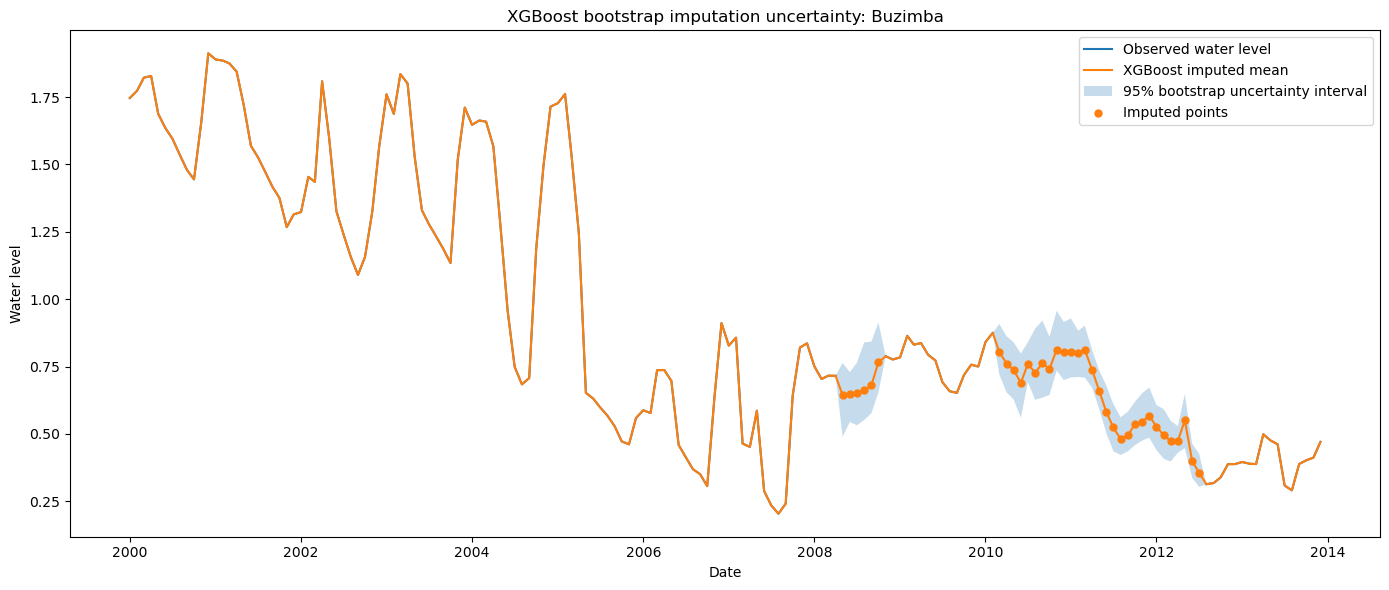

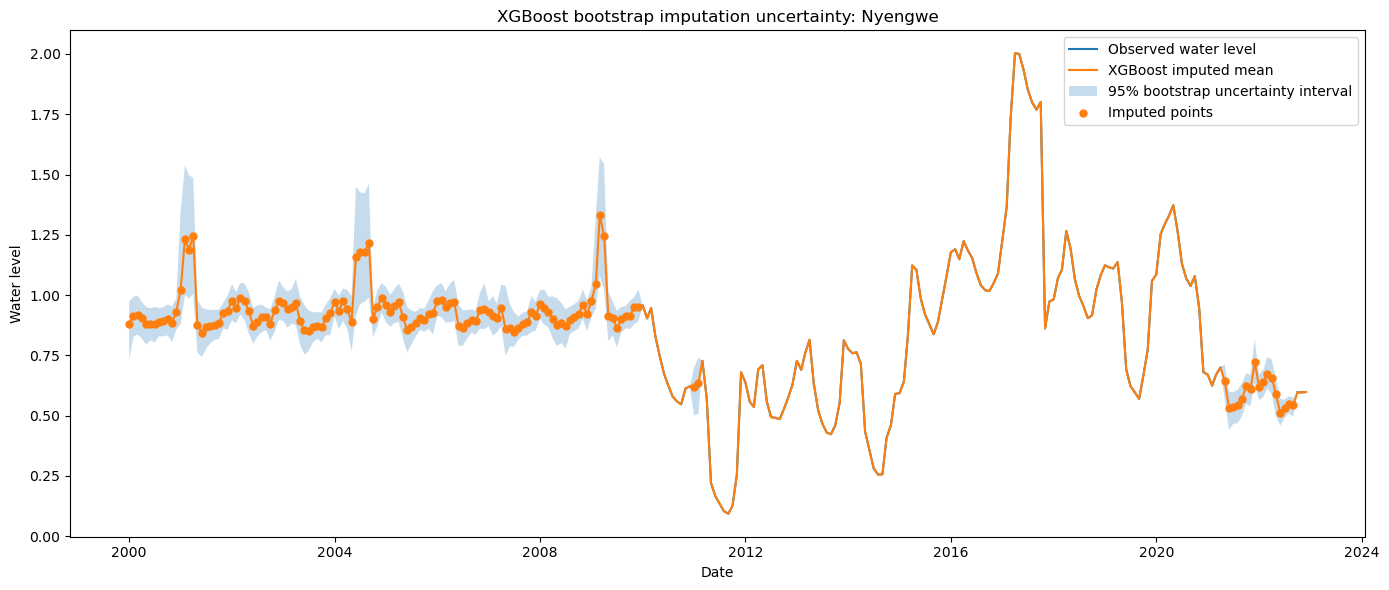

In [5]:
plot_xgb_imputation_uncertainty("Buzimba")
plot_xgb_imputation_uncertainty("Nyengwe")

In [9]:
# after bootstrap imputation section
rivers_imputed = xgb_uncertainty.copy()

rivers_imputed.head()

,river,year,month,water_level,runoff,temp_max_observed,temp_min_observed,precip_observed,temp_source,precip_source,...,precip_bias_factor,precip_imputed,ndvi,water_level_imputed_v2,wl_imputed_v2,water_level_m,water_level_xgb_mean,water_level_xgb_lower,water_level_xgb_upper,water_level_xgb_method
date,,,,,,,,,,,,,,,,,,,,,
2000-01-01,Nyamagana,2000,1,NaN,NaN,33.504850,15.512020,30.170508,MPARAMBO,MPARAMBO,...,2.186850,True,NaN,NaN,False,771.309,0.726642,0.517402,0.812767,XGBoost_bootstrap_ensemble
2000-01-01,Jiji,2000,1,0.704516,NaN,21.448387,9.948387,125.600000,MPOTA (Tora),MPOTA (Tora),...,0.746962,False,NaN,0.704516,False,771.309,0.704516,0.704516,0.704516,observed
2000-01-01,Kaburantwa,2000,1,NaN,0.71,33.504850,15.512020,30.459723,MPARAMBO,MPARAMBO,...,2.207814,True,NaN,NaN,False,771.309,1.515886,1.365585,1.594082,XGBoost_bootstrap_ensemble
2000-01-01,Mulembwe,2000,1,1.239355,20.05,21.448387,9.948387,125.600000,MPOTA (Tora),MPOTA (Tora),...,0.337618,False,NaN,1.239355,False,771.309,1.239355,1.239355,1.239355,observed
2000-01-01,Nyengwe,2000,1,NaN,12.99,28.367742,18.761290,203.000000,NYANZA LAC (IRAT),NYANZA LAC (IRAT),...,0.365854,False,NaN,NaN,False,771.309,0.880418,0.731529,0.972833,XGBoost_bootstrap_ensemble


# prediction 

In [10]:
# ============================================================
# DIRECT MULTI-HORIZON XGBOOST FORECASTING
# Horizons: 1, 3, 6 months ahead
# ============================================================

import numpy as np
import pandas as pd

from xgboost import XGBRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_squared_error, mean_absolute_error

# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

FORECAST_TARGET = "water_level_xgb_mean"
HORIZONS = [1, 3, 6]
TEST_YEARS = 5

# Reuse the global XGB_PARAMS defined in the validation cell.
# Kept as an alias so the rest of the cell does not need to change.
XGB_FORECAST_PARAMS = XGB_PARAMS


# ------------------------------------------------------------
# Forecast feature engineering
# ------------------------------------------------------------

def create_forecast_features(df, target_col=FORECAST_TARGET):
    df = df.copy()
    df = df.sort_index()

    # Seasonality
    df["month"] = df.index.month
    df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

    # Precipitation lags
    for lag in [1, 2, 3, 6, 12]:
        df[f"precip_lag{lag}"] = df["precip_observed"].shift(lag)

    # Rolling rainfall totals: previous months only
    df["precip_3m"] = df["precip_observed"].shift(1).rolling(3).sum()
    df["precip_6m"] = df["precip_observed"].shift(1).rolling(6).sum()
    df["precip_12m"] = df["precip_observed"].shift(1).rolling(12).sum()

    df["precip_weighted_3m"] = (
        df["precip_observed"].shift(1) * 0.5 +
        df["precip_observed"].shift(2) * 0.3 +
        df["precip_observed"].shift(3) * 0.2
    )

    # Water-level lags from the imputed complete series
    for lag in [1, 2, 3, 6, 12]:
        df[f"level_lag{lag}"] = df[target_col].shift(lag)

    # Rolling water level means: previous months only
    df["level_roll3"] = df[target_col].shift(1).rolling(3).mean()
    df["level_roll6"] = df[target_col].shift(1).rolling(6).mean()
    df["level_roll12"] = df[target_col].shift(1).rolling(12).mean()

    return df


forecast_predictors = [
    "temp_max_observed",
    "temp_min_observed",
    "precip_observed",
    "precip_lag1",
    "precip_lag2",
    "precip_lag3",
    "precip_lag6",
    "precip_lag12",
    "precip_3m",
    "precip_6m",
    "precip_12m",
    "precip_weighted_3m",
    "ndvi",
    "month",
    "month_sin",
    "month_cos",
    "level_lag1",
    "level_lag2",
    "level_lag3",
    "level_lag6",
    "level_lag12",
    "level_roll3",
    "level_roll6",
    "level_roll12"
]


# ------------------------------------------------------------
# Metrics
# ------------------------------------------------------------

def forecast_metrics(y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    bias = np.mean(y_pred - y_true)
    nse = 1 - np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2)

    return rmse, mae, bias, nse


# ------------------------------------------------------------
# Expanding-window direct forecasting
# ------------------------------------------------------------

forecast_results = []
forecast_predictions = []

for river_name in rivers_imputed[RIVER_COL].dropna().unique():

    df_river = rivers_imputed[
        rivers_imputed[RIVER_COL] == river_name
    ].copy()

    df_river = df_river.sort_index()
    df_river = df_river[df_river.index.year >= START_YEAR].copy()

    if df_river[FORECAST_TARGET].notna().sum() < MIN_OBS:
        print(f"Skipping {river_name}: not enough data.")
        continue

    df_features = create_forecast_features(df_river, target_col=FORECAST_TARGET)

    test_cutoff = df_features.index.max() - pd.DateOffset(years=TEST_YEARS)
    test_start_idx = np.where(df_features.index >= test_cutoff)[0][0]

    for h in HORIZONS:

        df_h = df_features.copy()

        # Direct multi-horizon target
        df_h[f"target_h{h}"] = df_h[FORECAST_TARGET].shift(-h)

        preds_for_horizon = []

        for train_end in range(test_start_idx - 1, len(df_h) - 1):

            target_idx = train_end + h

            if target_idx >= len(df_h):
                break

            # Only train on rows whose future target would be known at train_end
            train = df_h.iloc[: train_end - h + 1].copy()
            train = train.dropna(subset=[f"target_h{h}"])

            if len(train) < MIN_OBS:
                continue

            X_train = train[forecast_predictors]
            y_train = train[f"target_h{h}"]

            X_test = df_h.iloc[[train_end]][forecast_predictors]
            y_true = df_h.iloc[target_idx][FORECAST_TARGET]

            if pd.isna(y_true):
                continue

            imputer = SimpleImputer(strategy="mean")
            X_train_imp = imputer.fit_transform(X_train)
            X_test_imp = imputer.transform(X_test)

            model = XGBRegressor(**XGB_FORECAST_PARAMS)
            model.fit(X_train_imp, y_train)

            y_pred = model.predict(X_test_imp)[0]

            preds_for_horizon.append({
                "river": river_name,
                "forecast_origin": df_h.index[train_end],
                "target_date": df_h.index[target_idx],
                "horizon_months": h,
                "y_true": y_true,
                "y_pred": y_pred,
                "error": y_pred - y_true
            })

        if len(preds_for_horizon) == 0:
            print(f"No forecasts for {river_name}, horizon {h}.")
            continue

        pred_df = pd.DataFrame(preds_for_horizon)

        rmse, mae, bias, nse = forecast_metrics(
            pred_df["y_true"].values,
            pred_df["y_pred"].values
        )

        forecast_results.append({
            "river": river_name,
            "horizon_months": h,
            "n_forecasts": len(pred_df),
            "rmse": rmse,
            "mae": mae,
            "bias": bias,
            "nse": nse
        })

        forecast_predictions.append(pred_df)


# ------------------------------------------------------------
# Output tables
# ------------------------------------------------------------

forecast_results_df = pd.DataFrame(forecast_results)
forecast_predictions_df = pd.concat(forecast_predictions, ignore_index=True)

display(forecast_results_df)

overall_forecast_summary = (
    forecast_results_df
    .groupby("horizon_months")
    .agg(
        mean_rmse=("rmse", "mean"),
        median_rmse=("rmse", "median"),
        mean_mae=("mae", "mean"),
        median_mae=("mae", "median"),
        mean_bias=("bias", "mean"),
        mean_nse=("nse", "mean"),
        rivers_tested=("river", "nunique")
    )
    .reset_index()
)

display(overall_forecast_summary)

,river,horizon_months,n_forecasts,rmse,mae,bias,nse
0,Nyamagana,1,61,0.173794,0.133575,0.068954,0.506893
1,Nyamagana,3,59,0.209061,0.157615,0.117790,0.018648
2,Nyamagana,6,56,0.241861,0.195145,0.171003,-0.900182
3,Jiji,1,61,0.113704,0.080037,-0.020495,0.785131
4,Jiji,3,59,0.137129,0.090777,-0.046431,0.685533
5,Jiji,6,56,0.125068,0.080345,-0.045478,0.717016
6,Kaburantwa,1,61,0.191616,0.133267,0.014608,0.582891
7,Kaburantwa,3,59,0.292582,0.201045,0.023391,0.001168
8,Kaburantwa,6,56,0.329984,0.237635,0.086714,-0.658615
9,Mulembwe,1,61,0.230565,0.191035,-0.167437,0.626389


,horizon_months,mean_rmse,median_rmse,mean_mae,median_mae,mean_bias,mean_nse,rivers_tested
0,1,0.196594,0.176747,0.147797,0.133421,-0.035237,0.512394,10
1,3,0.299584,0.265052,0.229802,0.190583,-0.061229,-0.144855,10
2,6,0.334919,0.306116,0.266332,0.224070,-0.026545,-0.592796,10


# graphs 

In [11]:
# ============================================================
# PER-RIVER GRAPH DATA + GRAPHS
# 1. Raw data only, no imputation
# 2. Imputation with uncertainty
# 3. Prediction / forecast graphs
# Saves CSV + PNG per river
# ============================================================

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

OUTPUT_DIR = "river_graph_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

RAW_DIR = os.path.join(OUTPUT_DIR, "raw_no_imputation")
IMP_DIR = os.path.join(OUTPUT_DIR, "imputation_uncertainty")
PRED_DIR = os.path.join(OUTPUT_DIR, "prediction_forecasts")

for d in [RAW_DIR, IMP_DIR, PRED_DIR]:
    os.makedirs(d, exist_ok=True)


def safe_name(name):
    return re.sub(r"[^A-Za-z0-9_-]+", "_", str(name)).strip("_")


def save_fig(path):
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches="tight")
    plt.close()


# ============================================================
# 1. RAW DATA GRAPHS PER RIVER WITHOUT IMPUTATION
# ============================================================

for river_name in rivers_original[RIVER_COL].dropna().unique():

    df_raw = rivers_original[
        (rivers_original[RIVER_COL] == river_name) &
        (rivers_original.index.year >= START_YEAR)
    ].copy()

    df_raw = df_raw.sort_index()

    export_raw = (
        df_raw[[RIVER_COL, TARGET_COL]]
        .reset_index()
        .rename(columns={TARGET_COL: "raw_water_level"})
    )

    fname = safe_name(river_name)

    export_raw.to_csv(
        os.path.join(RAW_DIR, f"{fname}_raw_no_imputation.csv"),
        index=False
    )

    plt.figure(figsize=(14, 6))
    plt.plot(
        df_raw.index,
        df_raw[TARGET_COL],
        marker="o",
        linewidth=1.2,
        label="Observed raw water level"
    )

    plt.title(f"Raw water level without imputation: {river_name}")
    plt.xlabel("Date")
    plt.ylabel("Water level")
    plt.legend()

    save_fig(os.path.join(RAW_DIR, f"{fname}_raw_no_imputation.png"))


# ============================================================
# 2. IMPUTATION GRAPHS PER RIVER WITH UNCERTAINTY
# Uses xgb_uncertainty from your seed-ensemble section
# ============================================================

for river_name in xgb_uncertainty[RIVER_COL].dropna().unique():

    df_imp = xgb_uncertainty[
        (xgb_uncertainty[RIVER_COL] == river_name) &
        (xgb_uncertainty.index.year >= START_YEAR)
    ].copy()

    df_imp = df_imp.sort_index()

    if df_imp.empty:
        continue

    missing_mask = df_imp[TARGET_COL].isna()

    export_imp = df_imp[
        [
            RIVER_COL,
            TARGET_COL,
            "water_level_xgb_mean",
            "water_level_xgb_lower",
            "water_level_xgb_upper",
            "water_level_xgb_method"
        ]
    ].reset_index()

    export_imp = export_imp.rename(columns={
        TARGET_COL: "observed_water_level",
        "water_level_xgb_mean": "imputed_mean",
        "water_level_xgb_lower": "imputed_lower_95",
        "water_level_xgb_upper": "imputed_upper_95",
        "water_level_xgb_method": "method"
    })

    fname = safe_name(river_name)

    export_imp.to_csv(
        os.path.join(IMP_DIR, f"{fname}_imputation_uncertainty.csv"),
        index=False
    )

    plt.figure(figsize=(14, 6))

    plt.plot(
        df_imp.index,
        df_imp[TARGET_COL],
        linewidth=1.3,
        label="Observed water level"
    )

    plt.plot(
        df_imp.index,
        df_imp["water_level_xgb_mean"],
        linewidth=1.5,
        label="XGBoost imputed mean"
    )

    plt.fill_between(
        df_imp.index,
        df_imp["water_level_xgb_lower"],
        df_imp["water_level_xgb_upper"],
        alpha=0.25,
        label="95% uncertainty interval"
    )

    plt.scatter(
        df_imp.index[missing_mask],
        df_imp.loc[missing_mask, "water_level_xgb_mean"],
        s=25,
        label="Imputed points"
    )

    plt.title(f"Imputation with uncertainty: {river_name}")
    plt.xlabel("Date")
    plt.ylabel("Water level")
    plt.legend()

    save_fig(os.path.join(IMP_DIR, f"{fname}_imputation_uncertainty.png"))


# ============================================================
# 3. PREDICTION / FORECAST GRAPHS PER RIVER
# Uses forecast_predictions_df from your forecasting section
# ============================================================

for river_name in forecast_predictions_df[RIVER_COL].dropna().unique():

    df_pred = forecast_predictions_df[
        forecast_predictions_df[RIVER_COL] == river_name
    ].copy()

    df_pred = df_pred.sort_values(["horizon_months", "target_date"])

    if df_pred.empty:
        continue

    fname = safe_name(river_name)

    df_pred.to_csv(
        os.path.join(PRED_DIR, f"{fname}_prediction_forecasts.csv"),
        index=False
    )

    for h in sorted(df_pred["horizon_months"].unique()):

        df_h = df_pred[df_pred["horizon_months"] == h].copy()
        df_h = df_h.sort_values("target_date")

        df_h.to_csv(
            os.path.join(PRED_DIR, f"{fname}_prediction_h{h}_months.csv"),
            index=False
        )

        plt.figure(figsize=(14, 6))

        plt.plot(
            df_h["target_date"],
            df_h["y_true"],
            linewidth=1.5,
            label="True water level"
        )

        plt.plot(
            df_h["target_date"],
            df_h["y_pred"],
            linewidth=1.5,
            label=f"Predicted water level, {h}-month horizon"
        )

        plt.title(f"{h}-month prediction graph: {river_name}")
        plt.xlabel("Target date")
        plt.ylabel("Water level")
        plt.legend()

        save_fig(os.path.join(PRED_DIR, f"{fname}_prediction_h{h}_months.png"))


# ============================================================
# OPTIONAL: combined CSVs for easier checking
# ============================================================

raw_all = []
imp_all = []

for river_name in rivers_original[RIVER_COL].dropna().unique():
    df_raw = rivers_original[
        (rivers_original[RIVER_COL] == river_name) &
        (rivers_original.index.year >= START_YEAR)
    ][[RIVER_COL, TARGET_COL]].copy()

    raw_all.append(
        df_raw.reset_index().rename(columns={TARGET_COL: "raw_water_level"})
    )

for river_name in xgb_uncertainty[RIVER_COL].dropna().unique():
    df_imp = xgb_uncertainty[
        (xgb_uncertainty[RIVER_COL] == river_name) &
        (xgb_uncertainty.index.year >= START_YEAR)
    ][
        [
            RIVER_COL,
            TARGET_COL,
            "water_level_xgb_mean",
            "water_level_xgb_lower",
            "water_level_xgb_upper",
            "water_level_xgb_method"
        ]
    ].copy()

    imp_all.append(df_imp.reset_index())

pd.concat(raw_all, ignore_index=True).to_csv(
    os.path.join(OUTPUT_DIR, "ALL_raw_no_imputation.csv"),
    index=False
)

pd.concat(imp_all, ignore_index=True).to_csv(
    os.path.join(OUTPUT_DIR, "ALL_imputation_uncertainty.csv"),
    index=False
)

forecast_predictions_df.to_csv(
    os.path.join(OUTPUT_DIR, "ALL_prediction_forecasts.csv"),
    index=False
)

print(f"Done. Files saved in: {OUTPUT_DIR}")

Done. Files saved in: river_graph_outputs
